# Using Tradional Approach
## 1 = MSE
MSE score is the score between two representations of the audios.
Interpreting MSE score in perceptual loss for audio:
0 = perfect match(no difference)
Higher values = more difference


In [21]:
#Check the number of total files
import os

clean_folder = "/Users/taimurulislam/Desktop/MRSP_Seminar/clean_data"
noisy_folder = "/Users/taimurulislam/Desktop/MRSP_Seminar/noisy_data"

num_clean = len([f for f in os.listdir(clean_folder) if f.endswith('.wav')])
num_noisy = len([f for f in os.listdir(noisy_folder) if f.endswith('.wav')])

print(f"Total clean files: {num_clean}")
print(f"Total noisy files: {num_noisy}")


Total clean files: 94
Total noisy files: 94


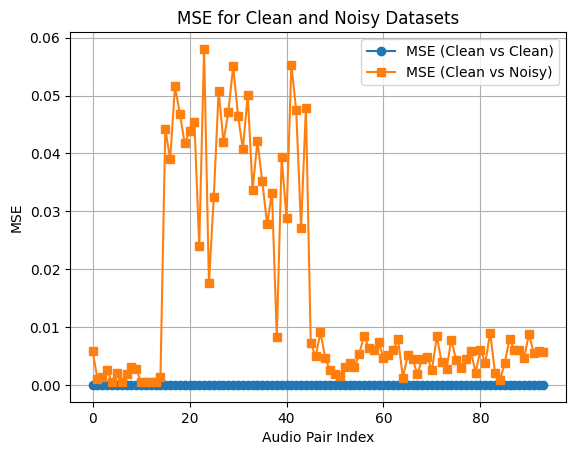

In [22]:
import glob
import librosa
import numpy as np
import matplotlib.pyplot as plt

# Paths
clean_folder = "/Users/taimurulislam/Desktop/MRSP_Seminar/clean_data"
noisy_folder = "/Users/taimurulislam/Desktop/MRSP_Seminar/noisy_data"

clean_files = sorted(glob.glob(f"{clean_folder}/*.wav"))
noisy_files = sorted(glob.glob(f"{noisy_folder}/*.wav"))

def compute_mse(clean, test):
    e = clean - test
    return float(np.mean(e**2))


mse_clean_vs_clean = []
mse_clean_vs_noisy = []

for c_file, n_file in zip(clean_files, noisy_files):
    clean, sr_c = librosa.load(c_file, sr=None)
    noisy, sr_n = librosa.load(n_file, sr=None)

    if sr_c != sr_n:
        noisy = librosa.resample(noisy, orig_sr=sr_n, target_sr=sr_c)

    min_len = min(len(clean), len(noisy))
    clean, noisy = clean[:min_len], noisy[:min_len]

    mse_clean_vs_clean.append(compute_mse(clean, clean))  # Should be 0
    mse_clean_vs_noisy.append(compute_mse(clean, noisy))

# Plot both MSE curves
x = np.arange(len(clean_files))

plt.figure()
plt.plot(x, mse_clean_vs_clean, marker='o', label="MSE (Clean vs Clean)")
plt.plot(x, mse_clean_vs_noisy, marker='s', label="MSE (Clean vs Noisy)")
plt.xlabel("Audio Pair Index"); plt.ylabel("MSE"); plt.title("MSE for Clean and Noisy Datasets")
plt.grid(True); plt.legend(); plt.show()


# 2 = SNR
In the context of perceptual loss between two audios, SNR (signal to noise ratio) measures how strong the original signal is compared to error.
Higher SNR = Better quality
Lower SNR = Poor quality (more distortion)
20-30 dB = generally good for audio, above 40 dB = high quality

In [16]:


def compute_snr_db(clean, test, eps=1e-12):
    e = clean - test
    P_sig = np.mean(clean**2) + eps   # reference (clean) power
    P_err = np.mean(e**2) + eps       # noise/error power
    return float(10*np.log10(P_sig / P_err))

sr = 16000
snr_clean_vs_clean_db = []
snr_clean_vs_noisy_db = []

for c_file, n_file in zip(clean_files, noisy_files):
    clean, _ = librosa.load(c_file, sr=sr, mono=True)
    noisy, _ = librosa.load(n_file, sr=sr, mono=True)
    m = min(len(clean), len(noisy))
    clean, noisy = clean[:m], noisy[:m]

    snr_clean_vs_clean_db.append(compute_snr_db(clean, clean))
    snr_clean_vs_noisy_db.append(compute_snr_db(clean, noisy))

x = np.arange(len(snr_clean_vs_noisy_db))


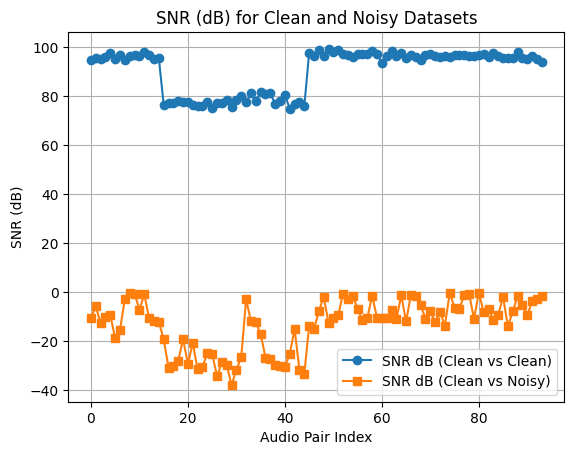

In [3]:
plt.figure()
plt.plot(x, snr_clean_vs_clean_db, marker='o', label="SNR dB (Clean vs Clean)")
plt.plot(x, snr_clean_vs_noisy_db, marker='s', label="SNR dB (Clean vs Noisy)")
plt.xlabel("Audio Pair Index"); plt.ylabel("SNR (dB)")
plt.title("SNR (dB) for Clean and Noisy Datasets")
plt.grid(True); plt.legend(); plt.show()


# Implement VGGish model for perceptual loss
It listens to your sound clip.
It converts it into a compact numerical fingerprint that describes how it sounds pitch, tone, timbre, rhythm.

In [4]:
!pip install tensorflow_hub


In [23]:
import tensorflow_hub as hub
import tensorflow as tf
from scipy.spatial.distance import cosine


vggish_model = hub.load('https://tfhub.dev/google/vggish/1')

def pad_audio(audio, target_len=16000):
    if len(audio) < target_len:
        padding = target_len - len(audio)
        audio = np.pad(audio, (0, padding), 'constant')
    else:
        audio = audio[:target_len]
    return audio

def extract_vggish_embedding(audio, sr):
    audio = pad_audio(audio)
    audio_tensor = tf.convert_to_tensor(audio, dtype=tf.float32)
    embeddings = vggish_model(audio_tensor)  # shape: (1, 128)
    embedding_vector = embeddings.numpy()
    embedding_vector = np.squeeze(embedding_vector)  # make sure shape is (128,)
    return embedding_vector
#Load data
clean_dir = '/Users/taimurulislam/Desktop/MRSP_Seminar/clean_data'
noisy_dir = '/Users/taimurulislam/Desktop/MRSP_Seminar/noisy_data'

clean_files = sorted([f for f in os.listdir(clean_dir) if f.endswith('.wav')])
noisy_files = sorted([f for f in os.listdir(noisy_dir) if f.endswith('.wav')])
losses = []
file_labels = []
for clean_file, noisy_file in zip(clean_files, noisy_files):
    clean_path = os.path.join(clean_dir, clean_file)
    noisy_path = os.path.join(noisy_dir, noisy_file)

    clean_audio, sr = librosa.load(clean_path, sr=16000)
    noisy_audio, _ = librosa.load(noisy_path, sr=16000)

    clean_emb = extract_vggish_embedding(clean_audio, sr)
    noisy_emb = extract_vggish_embedding(noisy_audio, sr)

    loss = cosine(clean_emb, noisy_emb)
    print(f'{clean_file} | Perceptual Loss: {loss:.4f}')
    losses.append(loss)
    file_labels.append(clean_file)


174-84280-0000.wav | Perceptual Loss: 0.4258
174-84280-0001.wav | Perceptual Loss: 0.1930
174-84280-0002.wav | Perceptual Loss: 0.4167
174-84280-0003.wav | Perceptual Loss: 0.3577
174-84280-0004.wav | Perceptual Loss: 0.4292
174-84280-0005.wav | Perceptual Loss: 0.2474
174-84280-0006.wav | Perceptual Loss: 0.4978
174-84280-0007.wav | Perceptual Loss: 0.5487
174-84280-0008.wav | Perceptual Loss: 0.3559
174-84280-0009.wav | Perceptual Loss: 0.3054
174-84280-0010.wav | Perceptual Loss: 0.4289
174-84280-0011.wav | Perceptual Loss: 0.2878
174-84280-0012.wav | Perceptual Loss: 0.4490
174-84280-0013.wav | Perceptual Loss: 0.2493
174-84280-0014.wav | Perceptual Loss: 0.3453
1993-147149-0000.wav | Perceptual Loss: 0.5789
1993-147149-0001.wav | Perceptual Loss: 0.5848
1993-147149-0002.wav | Perceptual Loss: 0.5455
1993-147149-0003.wav | Perceptual Loss: 0.4917
1993-147149-0004.wav | Perceptual Loss: 0.5089
1993-147149-0005.wav | Perceptual Loss: 0.5435
1993-147149-0006.wav | Perceptual Loss: 0.5

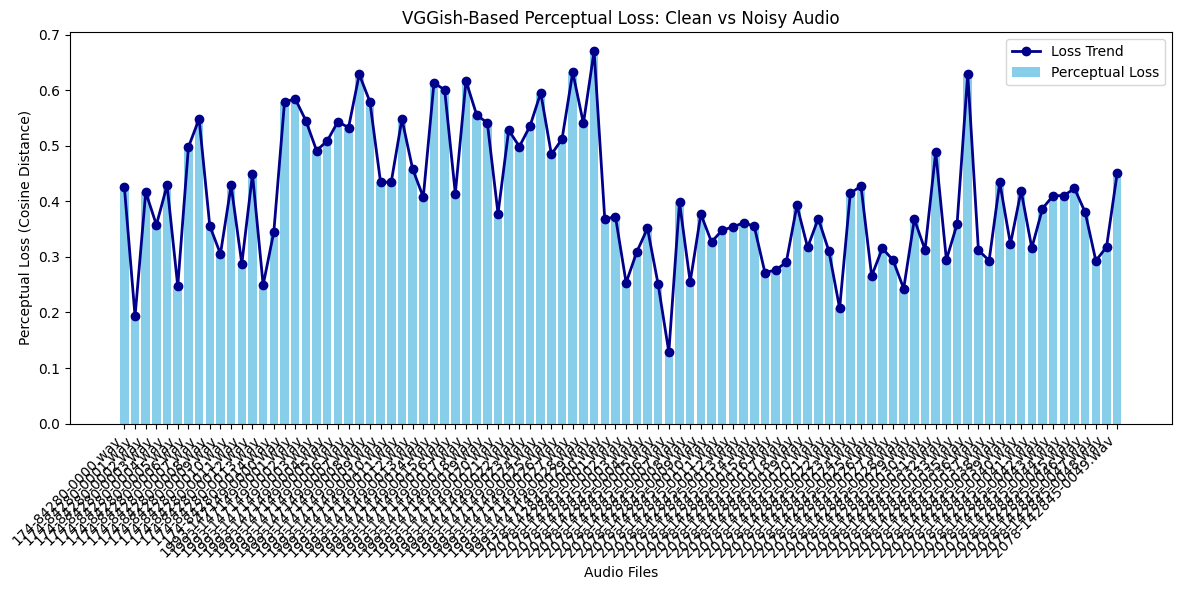

In [24]:
plt.figure(figsize=(12, 6))

x = range(len(losses))

# Colored bars for loss
bars = plt.bar(x, losses, color='skyblue', label='Perceptual Loss')

# Clear line plot over bars
plt.plot(x, losses, color='darkblue', marker='o', linewidth=2, label='Loss Trend')

plt.xticks(x, file_labels, rotation=45, ha='right')
plt.xlabel('Audio Files')
plt.ylabel('Perceptual Loss (Cosine Distance)')
plt.title('VGGish-Based Perceptual Loss: Clean vs Noisy Audio')

plt.legend()
plt.tight_layout()
plt.show()

# Comparison between tradional and VGGish model

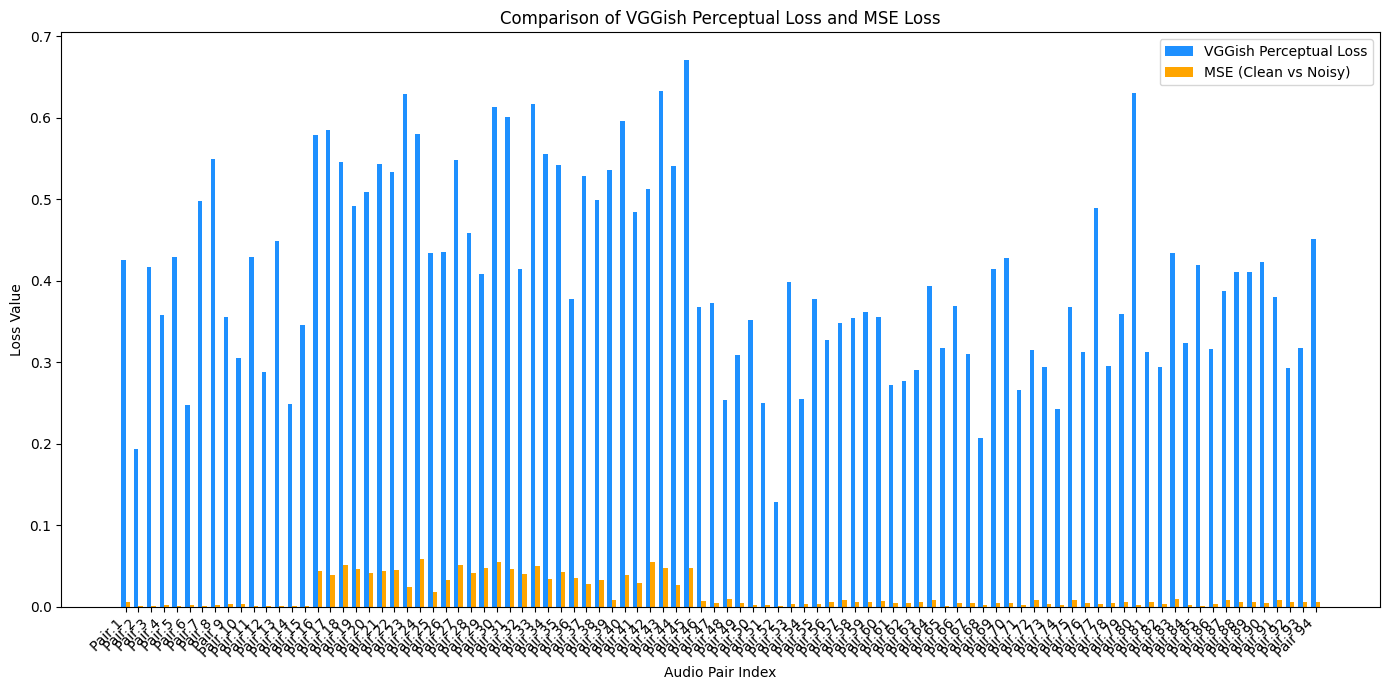

In [25]:



assert len(losses) == len(mse_clean_vs_noisy), "Length mismatch between losses lists"

labels = [f'Pair {i+1}' for i in range(len(losses))]
x = np.arange(len(labels))
width = 0.35  

plt.figure(figsize=(14, 7))


plt.bar(x - width/2, losses, width, label='VGGish Perceptual Loss', color='dodgerblue')

# Plot MSE bars (orange)
plt.bar(x + width/2, mse_clean_vs_noisy, width, label='MSE (Clean vs Noisy)', color='orange')

plt.xlabel('Audio Pair Index')
plt.ylabel('Loss Value')
plt.title('Comparison of VGGish Perceptual Loss and MSE Loss')
plt.xticks(x, labels, rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()
